___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# K Means Color Quantization

### Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

### The Image

In [2]:
image_as_array = mpimg.imread('../DATA/palm_trees.jpg')

In [3]:
image_as_array # RGB CODES FOR EACH PIXEL

array([[[ 25,  89, 127],
        [ 25,  89, 127],
        [ 25,  89, 127],
        ...,
        [ 23,  63,  98],
        [ 51,  91, 127],
        [ 50,  90, 126]],

       [[ 25,  89, 127],
        [ 25,  89, 127],
        [ 25,  89, 127],
        ...,
        [ 31,  71, 106],
        [ 48,  88, 124],
        [ 47,  90, 125]],

       [[ 25,  89, 127],
        [ 25,  89, 127],
        [ 25,  89, 127],
        ...,
        [ 39,  79, 114],
        [ 42,  85, 120],
        [ 44,  88, 123]],

       ...,

       [[  4,   4,   6],
        [  4,   4,   6],
        [  4,   4,   6],
        ...,
        [  9,   9,  11],
        [  9,   9,  11],
        [  9,   9,  11]],

       [[  3,   3,   5],
        [  3,   3,   5],
        [  3,   3,   5],
        ...,
        [  8,   8,  10],
        [  8,   8,  10],
        [  8,   8,  10]],

       [[  4,   4,   6],
        [  4,   4,   6],
        [  4,   4,   6],
        ...,
        [  9,   9,  11],
        [ 10,  10,  12],
        [ 10,  10,  12]]

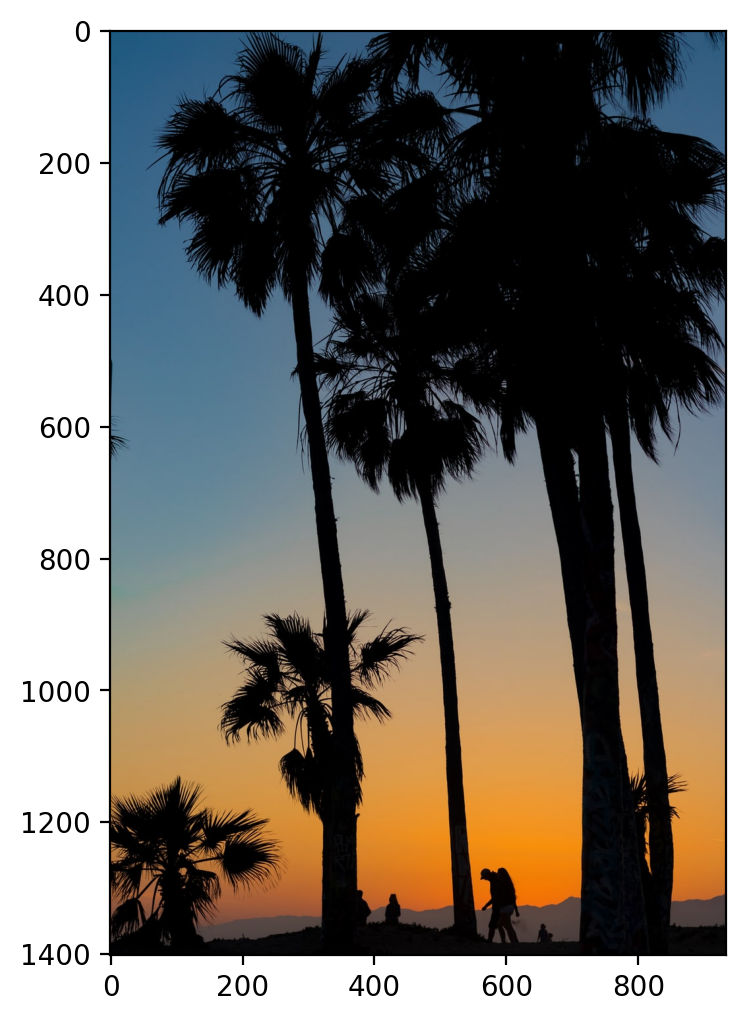

In [4]:
plt.figure(figsize=(6,6),dpi=200)
plt.imshow(image_as_array)

## Using Kmeans to Quantize Colors

Quantizing colors means we'll reduce the number of unique colors here to K unique colors. Let's try just 6 colors!

In [5]:
image_as_array.shape
# (h,w,3 color channels)

(1401, 934, 3)

### Convert from 3d to 2d

Kmeans is designed to train on 2D data (data rows and feature columns), so we can reshape the above strip by using (h,w,c) ---> (h * w,c)

In [6]:
(h,w,c) = image_as_array.shape
print(f"Height: {h}, Width: {w}, Color Channels: {c}")

Height: 1401, Width: 934, Color Channels: 3


In [7]:
image_as_array2d = image_as_array.reshape(h*w,c)

In [8]:
print(f"Total pixels: {h*w}")

Total pixels: 1308534


In [9]:
len(image_as_array.shape) # 3D array (height, width, color channels)

3

In [10]:
len(image_as_array2d.shape) # 2D array (number of pixels, color channels)

2

In [11]:
from sklearn.cluster import KMeans

# Choosing K Value

In [12]:
ssd = []

for k in range(2,20):
    
    model = KMeans(n_clusters=k)
    
    
    model.fit(image_as_array2d)
    
    #Sum of squared distances of samples to their closest cluster center.
    ssd.append(model.inertia_)

Text(0, 0.5, ' Sum of Squared Distances')

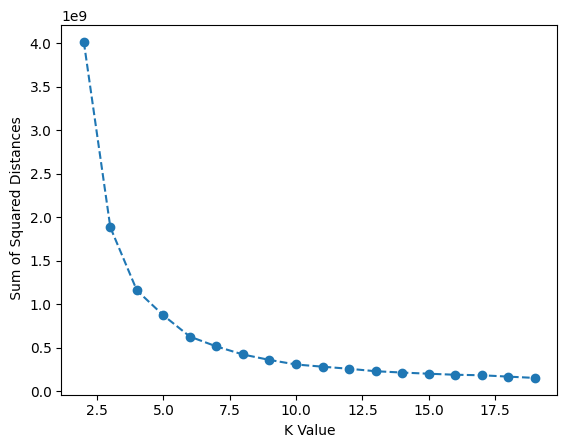

In [13]:
plt.plot(range(2,20),ssd,'o--')
plt.xlabel("K Value")
plt.ylabel(" Sum of Squared Distances")
# With this plot we can choose the optimal K value for our KMeans model. 
# We look for the "elbow" point where the sum of squared distances starts to decrease more slowly. 
# In this case, it seems that the elbow point is around K=5 or K=6, which suggests that these values may be good choices for the number of clusters in our KMeans model.

In [14]:
ssd

[4017322041.636988,
 1884248633.5914774,
 1159598495.8885996,
 872476389.0090858,
 628274112.977618,
 515168720.21506095,
 422562831.93439233,
 360158234.84262294,
 307617785.7826096,
 282430732.13626605,
 258392933.42754567,
 230349202.69167173,
 214983149.85910124,
 201579679.1416523,
 189644543.61385697,
 183755616.281085,
 168153773.01001737,
 153193685.43540293]

In [15]:
pd.Series(ssd).diff()

0              NaN
1    -2.133073e+09
2    -7.246501e+08
3    -2.871221e+08
4    -2.442023e+08
5    -1.131054e+08
6    -9.260589e+07
7    -6.240460e+07
8    -5.254045e+07
9    -2.518705e+07
10   -2.403780e+07
11   -2.804373e+07
12   -1.536605e+07
13   -1.340347e+07
14   -1.193514e+07
15   -5.888927e+06
16   -1.560184e+07
17   -1.496009e+07
dtype: float64

In [16]:
pd.Series(ssd).pct_change() * 100

0           NaN
1    -53.096899
2    -38.458308
3    -24.760476
4    -27.989557
5    -18.002555
6    -17.975837
7    -14.768123
8    -14.588157
9     -8.187775
10    -8.511042
11   -10.853134
12    -6.670764
13    -6.234661
14    -5.920803
15    -3.105245
16    -8.490540
17    -8.896671
dtype: float64

<Axes: >

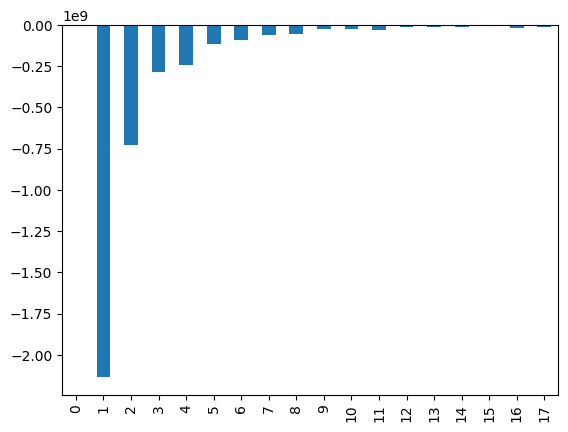

In [17]:
pd.Series(ssd).diff().plot(kind='bar')
# This this plot shows the change in the sum of squared distances as we increase the number of clusters (K).
# The bars represent the difference in the sum of squared distances between consecutive K values.
# We can see that the optimal K value is around 5 or 6, where the change in the sum of squared distances starts to decrease more significantly.
# We will choose K=5 for our KMeans model based on this analysis, to contrast the diference with the before excersise where we chose K=6.

In [18]:
# We will choose K=5 for our KMeans model based on this analysis, to contrast the diference with the before excersise where we chose K=6.
model = KMeans(n_clusters=5)

In [19]:
model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [20]:
labels = model.fit_predict(image_as_array2d)

In [21]:
labels

array([2, 2, 2, ..., 0, 0, 0], shape=(1308534,), dtype=int32)

In [22]:
# THESE ARE THE 6 RGB COLOR CODES!
model.cluster_centers_

array([[  3.46761498,   3.19256057,   4.26897163],
       [166.28099132, 151.62105017, 130.90839422],
       [ 61.91686825,  80.08313938,  97.37657293],
       [214.30058809, 140.75784014,  60.7431561 ],
       [ 96.14162899, 125.90548243, 145.51426633]])

In [23]:
rgb_codes = model.cluster_centers_.round(0).astype(int)

In [24]:
rgb_codes

array([[  3,   3,   4],
       [166, 152, 131],
       [ 62,  80,  97],
       [214, 141,  61],
       [ 96, 126, 146]])

In [25]:
rgb_codes[labels]

array([[62, 80, 97],
       [62, 80, 97],
       [62, 80, 97],
       ...,
       [ 3,  3,  4],
       [ 3,  3,  4],
       [ 3,  3,  4]], shape=(1308534, 3))

In [26]:
quantized_image = np.reshape(rgb_codes[labels], (h, w, c))

In [27]:
quantized_image

array([[[62, 80, 97],
        [62, 80, 97],
        [62, 80, 97],
        ...,
        [62, 80, 97],
        [62, 80, 97],
        [62, 80, 97]],

       [[62, 80, 97],
        [62, 80, 97],
        [62, 80, 97],
        ...,
        [62, 80, 97],
        [62, 80, 97],
        [62, 80, 97]],

       [[62, 80, 97],
        [62, 80, 97],
        [62, 80, 97],
        ...,
        [62, 80, 97],
        [62, 80, 97],
        [62, 80, 97]],

       ...,

       [[ 3,  3,  4],
        [ 3,  3,  4],
        [ 3,  3,  4],
        ...,
        [ 3,  3,  4],
        [ 3,  3,  4],
        [ 3,  3,  4]],

       [[ 3,  3,  4],
        [ 3,  3,  4],
        [ 3,  3,  4],
        ...,
        [ 3,  3,  4],
        [ 3,  3,  4],
        [ 3,  3,  4]],

       [[ 3,  3,  4],
        [ 3,  3,  4],
        [ 3,  3,  4],
        ...,
        [ 3,  3,  4],
        [ 3,  3,  4],
        [ 3,  3,  4]]], shape=(1401, 934, 3))

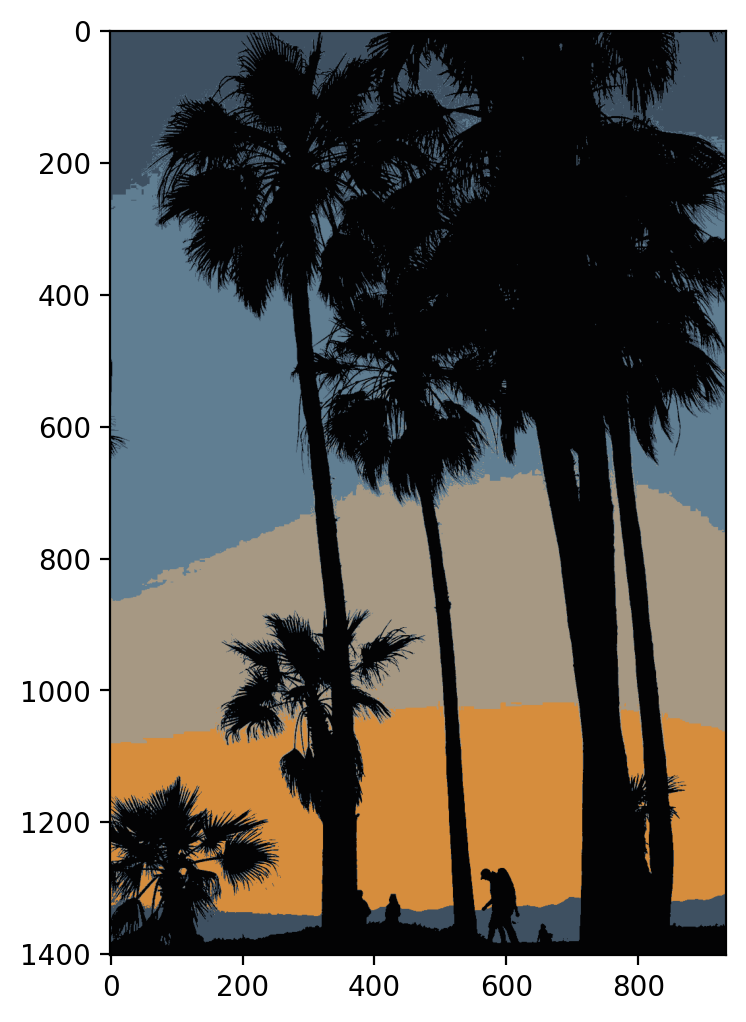

In [ ]:
plt.figure(figsize=(6,6),dpi=200)
plt.imshow(quantized_image)
# In this image, we can see that the colors have been reduced to 5 distinct colors, which are represented by the RGB codes in the cluster centers.
# But in the before excersise where we chose K=6, we had better color representation, with more distinct colors. This shows that choosing the optimal K value is important for achieving good results in KMeans clustering.
# For that reason is important to contrast the results of different K values to see the impact on the final output.